In [1]:
from utils import *

n=50


<h1 align='center'> Dimension </h1>

This already controls for character in that they are balanced across the condition types (within dimension and between dimension)

## Temporal and character familiarity similarity can't explain the dimension effect

In [ ]:
# plot the individual trials
affil = remove_neutral_trials((decision_trials['dimension'] == 'affil').values.astype(int))[:, np.newaxis]
fig, ax = plt.subplots(figsize=(10, 2))
ax.plot(affil)
ax.set_title('Social Dimensions')
plt.show()

dim_rdm = pairwise_distances(affil, metric='hamming')
dim_rdv = flatten_upper_tri(dim_rdm)

# compare dimensions on familiarity
familiarity      = remove_neutral_trials(decision_trials['character_decision_num'].values)
familiarity_rdm  = pairwise_distances(familiarity.reshape(-1, 1), metric='euclidean')
familiarity_rdv  = flatten_upper_tri(familiarity_rdm)
familiarity_same = familiarity_rdv[dim_rdv==1]
familiarity_diff = familiarity_rdv[dim_rdv==0]

p = scipy.stats.levene(familiarity_same, familiarity_diff)[1]
print(f'Levene test for equal variance: p={p:.3f}')
t, p = scipy.stats.ttest_ind(familiarity_same, familiarity_diff, equal_var=True)
print(f'T-test for familiarity difference: t={t:.3f}, p={p:.3f}')

# compare dimensions on onsets
onsets     = remove_neutral_trials(decision_trials['onset'].values)
onset_rdm  = pairwise_distances(onsets.reshape(-1, 1), metric='euclidean')
onset_rdv  = flatten_upper_tri(onset_rdm)
onset_same = onset_rdv[dim_rdv==1]
onset_diff = onset_rdv[dim_rdv==0]

p = scipy.stats.levene(onset_same, onset_diff)[1]
print(f'Levene test for equal variance: p={p:.3f}')
t, p = scipy.stats.ttest_ind(onset_same, onset_diff, equal_var=True) # even 1-sided isnt significant
print(f'T-test for onset closeness: t={t:.3f}, left-tailed p={p:.3f}')


#-------------
# plot heatmap
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

ax = axs[0]
sns.heatmap(dim_rdm, cmap='Greys', square=True, ax=ax)
ax.set(title='Dimensionality RDM', xlabel='Trial', ylabel='Trial')
ax.collections[0].colorbar.remove()

ax = axs[1]
sns.heatmap(familiarity_rdm, cmap='Greys', square=True, ax=ax)
ax.set(title='Familiarity RDM', xlabel='Trial', ylabel='Trial')
ax.collections[0].colorbar.remove()

ax = axs[2]
sns.heatmap(onset_rdm, cmap='Greys', square=True, ax=ax)
ax.set(title='Onset RDM', xlabel='Trial', ylabel='Trial')
ax.collections[0].colorbar.remove()
plt.show()

## Word count can't explain it

In [ ]:
affil_mask = decision_trials['dimension'] == 'affil'
power_mask = decision_trials['dimension'] == 'power'

In [ ]:
# import Dict from typing
from typing import Dict
def replace_pronouns(df: pd.DataFrame, character_genders: Dict[str, str]) -> pd.DataFrame:
    """
    Replace bracketed placeholders in columns ['text','opt1_text','opt2_text'] using only
    the provided character_genders mapping:
      {'First': 'man'/'woman', 'Second': ..., 'Assistant': ..., 'Newcomb': ..., 'Hayworth': ..., 'Neutral': ...}

    Behavior
    --------
    • Pronouns for each role (subject/object/possessives/reflexive) and contractions ('is','would','will')
    • Titles/specials: [Mr./Mrs. X character], [X character sir/ma'am], [X character guy/girl], [X character man/woman]
    • Names:
        - First & Second:     man→Chris  | woman→Jessica
        - Assistant & Neutral: man→Anthony | woman→Kayce
        - Newcomb & Hayworth: fixed "Newcomb" / "Hayworth"
      Replaces: [X character name], [X character first name]
    • Newcomb possessive: [Newcomb character possessive] → "Newcomb's"
      (others: → his/her according to gender)
    • Newcomb spouse: opposite Newcomb gender; name = "James" (man) or "Mary" (woman)
      Replaces: [Newcomb character spouse's name], [Newcomb character spouse's pronoun]
    • Any unrecognized tokens are left as-is.

    Notes
    -----
    • Female title is "Mrs." (per your preference).
    """

    required_cols = {'text','opt1_text','opt2_text'}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")

    # ---------- helpers ----------
    def forms_for_gender(g: str):
        g = (g or '').strip().lower()
        if g == 'woman':
            return dict(
                subj='she', obj='her', poss_det='her', poss_pron='hers', refl='herself',
                is_contr="she's", would_contr="she'd", will_contr="she'll",
                guy_girl='girl', sir_maam="ma'am", man_woman='woman', mr_mrs='Mrs.'
            )
        # default to 'man'
        return dict(
            subj='he', obj='him', poss_det='his', poss_pron='his', refl='himself',
            is_contr="he's", would_contr="he'd", will_contr="he'll",
            guy_girl='guy', sir_maam='sir', man_woman='man', mr_mrs='Mr.'
        )

    def name_for_role(role: str, gender: str) -> str:
        gender = (gender or 'man').lower()
        if role in ('First', 'Second'):
            return 'Chris' if gender == 'man' else 'Jessica'
        if role in ('Assistant', 'Neutral'):
            return 'Anthony' if gender == 'man' else 'Kayce'
        if role == 'Newcomb':
            return 'Newcomb'
        if role == 'Hayworth':
            return 'Hayworth'
        # fallback
        return role

    roles = ['First','Second','Assistant','Newcomb','Hayworth','Neutral']
    role_forms = {r: forms_for_gender(character_genders.get(r, 'man')) for r in roles}
    role_names = {r: name_for_role(r, character_genders.get(r, 'man')) for r in roles}

    # Newcomb spouse (opposite gender)
    newcomb_gender = (character_genders.get('Newcomb','man') or 'man').lower()
    spouse_gender = 'woman' if newcomb_gender == 'man' else 'man'
    spouse_forms = forms_for_gender(spouse_gender)
    spouse_name = 'Mary' if spouse_gender == 'woman' else 'James'

    # ---------- build replacement rules ----------
    replacements = []
    def pat(token: str) -> re.Pattern:
        return re.compile(re.escape(token))

    for role in roles:
        f = role_forms[role]
        nm = role_names[role]
        # Core pronouns + contractions
        mapping = {
            f'[{role} character pronoun]': f['subj'],
            f'[{role} character objective]': f['obj'],
            f'[{role} character reflexive]': f['refl'],
            f'[{role} character possessive pronoun]': f['poss_pron'],
            f'[{role} character possessive determiner]': f['poss_det'],
            f'[{role} character \'is\' contraction]': f['is_contr'],
            f'[{role} character \'would\' contraction]': f['would_contr'],
            f'[{role} character \'will\' contraction]': f['will_contr'],
            f'[Mr./Mrs. {role} character]': f['mr_mrs'],
            f'[{role} character sir/ma\'am]': f['sir_maam'],
            f'[{role} character guy/girl]': f['guy_girl'],
            f'[{role} character man/woman]': f['man_woman'],
            f'[{role} character name]': nm,
            f'[{role} character first name]': nm,
        }
        # Generic "[X character possessive]" → pronoun poss. determiner, except Newcomb handled later
        if role != 'Newcomb':
            mapping[f'[{role} character possessive]'] = f['poss_det']

        for k, v in mapping.items():
            replacements.append((pat(k), v))

    # Newcomb-specific overrides & spouse
    replacements.append((pat('[Newcomb character possessive]'), "Newcomb's"))
    replacements.append((pat("[Newcomb character spouse's name]"), spouse_name))
    replacements.append((pat("[Newcomb character spouse's pronoun]"), spouse_forms['subj']))

    # Also ensure explicit tokens common in your script map correctly
    replacements.append((pat("[Hayworth character sir/ma'am]"), role_forms['Hayworth']['sir_maam']))
    replacements.append((pat('[Second character guy/girl]'), role_forms['Second']['guy_girl']))
    replacements.append((pat('[Newcomb character man/woman]'), role_forms['Newcomb']['man_woman']))

    # Cleanup: collapse double spaces that might arise after substitutions
    space_fix = re.compile(r' {2,}')

    def _apply(text):
        if not isinstance(text, str):
            return text
        out = text
        for rx, repl in replacements:
            out = rx.sub(repl, out)
        out = space_fix.sub(' ', out)
        return out

    out = df.copy()
    for col in ['text','opt1_text','opt2_text']:
        out[col] = out[col].map(_apply)

    return out

from nltk.tokenize import word_tokenize, sent_tokenize

# get the text for the decision trials
character_genders = {'First': 'man', 'Second': 'woman', 'Assistant': 'man',
                    'Newcomb': 'woman', 'Hayworth': 'man', 'Neutral': 'woman'}
decision_trials = replace_pronouns(decision_trials, character_genders)
affil_df   = decision_trials[affil_mask].reset_index(drop=True)
power_df   = decision_trials[power_mask].reset_index(drop=True)
assert affil_df.shape[0] == power_df.shape[0]

# number of words
affil_wc = np.array([len(set(word_tokenize(text))) for text in affil_df['text'].values])
power_wc = np.array([len(set(word_tokenize(text))) for text in power_df['text'].values])

print("Mean affiliation words:", affil_wc.mean())
print("Mean power words:", power_wc.mean())
t_stat, p = scipy.stats.ttest_ind(affil_wc, power_wc, alternative='two-sided')
print(f'Word count: t={t_stat:.3f}, p={p:.3f}')

## Sentiment can't explain it

In [ ]:
#---------------------------------------- sentiment analysis

from transformers import pipeline
sentiment_model = pipeline("sentiment-analysis", 
                           model="cardiffnlp/twitter-roberta-base-sentiment", 
                           return_all_scores=True) 

def calculate_compound_score(sentiment):
    
    positive = sentiment[[k for k in sentiment.keys() if 'positivity' in k][0]]
    negative = sentiment[[k for k in sentiment.keys() if 'negativity' in k][0]]
    neutral  = sentiment[[k for k in sentiment.keys() if 'neutrality' in k][0]]

    # Normalize scores --> probabilities
    total = positive + negative + neutral
    positive_norm = positive / total
    negative_norm = negative / total
    neutral_norm  = neutral / total
    
    # Simple compound score calculation
    # - scale by neutral to reduce the compound score when the sentiment is mostly neutral
    compound_score = (positive_norm - negative_norm) * (1 - neutral_norm)
    return np.round(compound_score, 3)

def run_sentiment_analysis(text):
    sentiment = sentiment_model(text)[0]
    sentiment = {sent['label']: np.round(sent['score'], 3) for sent in sentiment}
    label_mapping = {'LABEL_0': 'negativity', 'LABEL_1': 'neutrality', 'LABEL_2': 'positivity'} 
    sentiment = {label_mapping[k]: v for k, v in sentiment.items() if k in label_mapping}
    sentiment['compound'] = calculate_compound_score(sentiment)
    return sentiment

sentiments = [run_sentiment_analysis(text) for text in decision_trials['text']]
sentiment_df = pd.DataFrame(sentiments)
decision_trials[sentiment_df.columns] = sentiment_df


# compare affil and pwoer on compound 
t_stat, p = scipy.stats.ttest_ind(decision_trials.loc[affil_mask, 'compound'], 
                                  decision_trials.loc[power_mask, 'compound'], 
                                  alternative='two-sided')
print(f'Compound sentiment: t={t_stat:.3f}, p={p:.3f}')

## Semantics are different, as expected

In [ ]:
snt_df = pd.read_excel(f'{data_dir}/info/social-navigation-task.xlsx')
snt_df = snt_df[np.isfinite(snt_df['trial_num'])]
snt_df.sort_values(by='onset', inplace=True)
decision_mask = (snt_df['slide_type'] == 'Decision').values
affil_decisions = ((decision_trials['dimension'] == 'affil').values)*1

model_names  = ['mpnet', 'google']
semantic_dict = load_pickle(f'../data/narratives/task-embeddings/generic_narrative_embeddings_1slide-context.pkl')


# Permutation test function that works with pre-computed dimension RDV
def permutation_test_dimension_similarity(vectors, dimension_labels, n_permutations=1000):
    """
    Run a permutation test to determine if within-dimension similarity is greater than between-dimension similarity.
    
    Parameters:
    -----------
    vectors : ndarray
        Decision vectors with shape (n_samples, n_features)
    dimension_labels : ndarray
        Binary column vector indicating the dimension of each vector (e.g., affil_decisions)
    n_permutations : int
        Number of permutations to run
    
    Returns:
    --------
    observed_diff : float
        Observed difference between within-dimension and between-dimension similarities
    p_value : float
        P-value from the permutation test
    null_diffs : ndarray
        Distribution of differences under the null hypothesis
    """
    # Calculate pairwise cosine similarities (1 - cosine distance)
    similarity_matrix = 1 - pairwise_distances(vectors, metric='cosine')
    
    # Convert dimension labels to a vector if it's a column
    if dimension_labels.ndim > 1 and dimension_labels.shape[1] == 1:
        dimension_labels = dimension_labels.ravel()
    
    # Create dimension RDV: 0 if same dimension, 1 if different
    dimension_rdv = flatten_upper_tri(pairwise_distances(dimension_labels[:, np.newaxis], metric='hamming'))
    
    # Get similarity values (upper triangular, excluding diagonal)
    similarity_values = flatten_upper_tri(similarity_matrix)
    
    # Separate within and between similarities
    within_similarities = similarity_values[dimension_rdv == 0]  # Same dimension (0 distance)
    between_similarities = similarity_values[dimension_rdv == 1]  # Different dimensions (1 distance)
    
    # Calculate observed statistic: difference between within and between similarities
    observed_diff = np.mean(within_similarities) - np.mean(between_similarities)
    
    # Permutation test
    null_diffs = np.zeros(n_permutations)
    for i in tqdm(range(n_permutations), desc="Running permutations"):
        # Permute dimension labels
        permuted_labels = np.random.permutation(dimension_labels)
        
        # Create permuted dimension RDV
        permuted_rdv = flatten_upper_tri(pairwise_distances(permuted_labels[:, np.newaxis], metric='hamming'))
        
        # Calculate null difference
        null_within = similarity_values[permuted_rdv == 0]
        null_between = similarity_values[permuted_rdv == 1]
        null_diffs[i] = np.mean(null_within) - np.mean(null_between)
    
    # Calculate p-value
    p_value = np.mean(null_diffs >= observed_diff)
    
    return observed_diff, p_value, null_diffs

# Modified main analysis
def run_permutation_analysis(semantic_vectors, decision_mask, affil_decisions, n_permutations=1000):
    """Run the permutation analysis for all models."""
    results = []
    
    for model_name, vectors in semantic_vectors.items():

        if model_name == 'text':
            continue  # Skip the text entries

        # Extract decision vectors
        decision_vectors = remove_neutral_trials(vectors[decision_mask])
        
        # Get the binary dimension labels that correspond to the decision vectors
        dimension_labels = remove_neutral_trials(affil_decisions)
        
        # Make sure vectors and labels match in length
        assert len(decision_vectors) == len(dimension_labels), f"Mismatch in dimensions: {len(decision_vectors)} vectors but {len(dimension_labels)} labels"
        
        # Run permutation test
        diff, p_value, null_distribution = permutation_test_dimension_similarity(
            decision_vectors, dimension_labels, n_permutations
        )
        
        # Store results
        results.append({
            'model': model_name,
            'diff': diff,
            'p_value': p_value,
            'null_distribution': null_distribution
        })
    
    return results

results = run_permutation_analysis(semantic_dict, decision_mask, affil_decisions, n_permutations=1000)

# Create DataFrame for results summary
summary_df = pd.DataFrame([
    {'model': r['model'], 'diff': r['diff'], 'p_value': r['p_value']}
    for r in results
])

fig, axs = plt.subplots(len(results), 1, figsize=(6, 3* len(results)))
for i, result in enumerate(results):
    ax = axs[i]
    sns.histplot(result['null_distribution'], ax=ax, bins=30, kde=True)
    ax.axvline(result['diff'], color='red', linestyle='--')
    # add text next to the line result['diff']
    ax.text(result['diff'], ax.get_ylim()[1] * 0.8, f"{result['diff']:.4f}", color='red')
    ax.set_title(f"Model: {result['model']}, p = {result['p_value']:.4f}")
    ax.set_xlabel("Within - Between similarity difference")
    ax.set_ylabel("Frequency")
plt.tight_layout()


## Behavioral reaction time is a confound

In [ ]:
rt_diffs = []
for sub_id in data['sub_id'].values:
    behav = load_behavior(sub_id, neutrals=False)
    behav = behav[behav['responded']].reset_index()
    affil_rts = behav[behav['dimension'] == 'affil']['reaction_time']
    power_rts = behav[behav['dimension'] == 'power']['reaction_time']
    rt_diffs.append([sub_id, np.mean(affil_rts), np.mean(power_rts)])
rt_df = pd.DataFrame(rt_diffs, columns=['sub_id', 'affil_rt', 'power_rt'])
# print the means
print(rt_df[['affil_rt', 'power_rt']].mean())

t, p = scipy.stats.ttest_rel(rt_df['affil_rt'], rt_df['power_rt'])
print(f'RT difference: t={t:.3f}, p={p:.3f}')
fig, ax = plt.subplots(figsize=(5, 3))
sns.histplot(rt_df['affil_rt'], color='blue', ax=ax, label='Affil')
sns.histplot(rt_df['power_rt'], color='red', ax=ax, label='Power')
ax.set(title='Reaction Times', xlabel='Mean RT', ylabel='Count')
plt.legend();

<h1 align='center'> Location distance </h1>

In [2]:
from scipy.spatial.distance import pdist, squareform
from scipy.stats import kendalltau, spearmanr, pearsonr, rankdata
from sklearn.linear_model import LinearRegression

corr_method = "pearson"
corr_func = pearsonr
def corr_and_p(x, y, method="pearson"):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return np.nan, np.nan
    if method == "pearson":
        r, p = pearsonr(x[m], y[m])
    elif method == "spearman":
        r, p = spearmanr(x[m], y[m])
    else:
        raise ValueError(f"Unknown method: {method}")
    return float(r), float(p)

def stars_from_p(p):
    if not np.isfinite(p):
        return ""
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return ""

def corr_only(a, b):
    r = corr_func(a, b)
    return float(getattr(r, "correlation", r[0] if isinstance(r, (tuple, list)) else r))


## possible confound distances

In [3]:
def time_poly_basis(onsets, degrees=(1, 2), eps=1e-12):
    """
    Return array with columns for |Δt|^d where higher orders are residualized
    on all lower orders (with intercept). Optionally z-score columns.
    Shape: [n_pairs, len(degrees)].
    """
    def orth_residualize(x, *others):
        n = len(x)
        if not others:
            return x - x.mean()
        X = np.column_stack([np.ones(n), *others])
        beta, *_ = np.linalg.lstsq(X, x, rcond=None)
        return x - X @ beta

    def zscore(x):
        x = np.asarray(x, float)
        return (x - x.mean()) / (x.std(ddof=1) + eps)

    dt   = pdist(np.asarray(onsets, float).reshape(-1, 1), metric='euclidean')
    degs = tuple(sorted(degrees))

    cols = []
    for j, d in enumerate(degs):
        x = dt ** d
        if j > 0:  # make 'unique' by removing projections on lower orders
            x = orth_residualize(x, *cols)
        cols.append(x)
    return np.column_stack(cols)

def per_character_rdvs(char_id_vec):
    """
    Return dict {character_value: rdv_vector} where each RDV is 1 for
    within-character pairs (both endpoints == that character), else 0.

    The RDVs are in SciPy's condensed order (same as pdist).
    """
    char_id_vec = np.asarray(char_id_vec)
    chars = np.unique(char_id_vec)
    out = {}
    for c in chars:
        mask = (char_id_vec == c).astype(float)  # length T
        M = np.outer(mask, mask)                 # T x T, 1 only if both endpoints are c
        np.fill_diagonal(M, 0.0)                 # hollow
        out[c] = squareform(M, checks=False).astype(float)
    return out


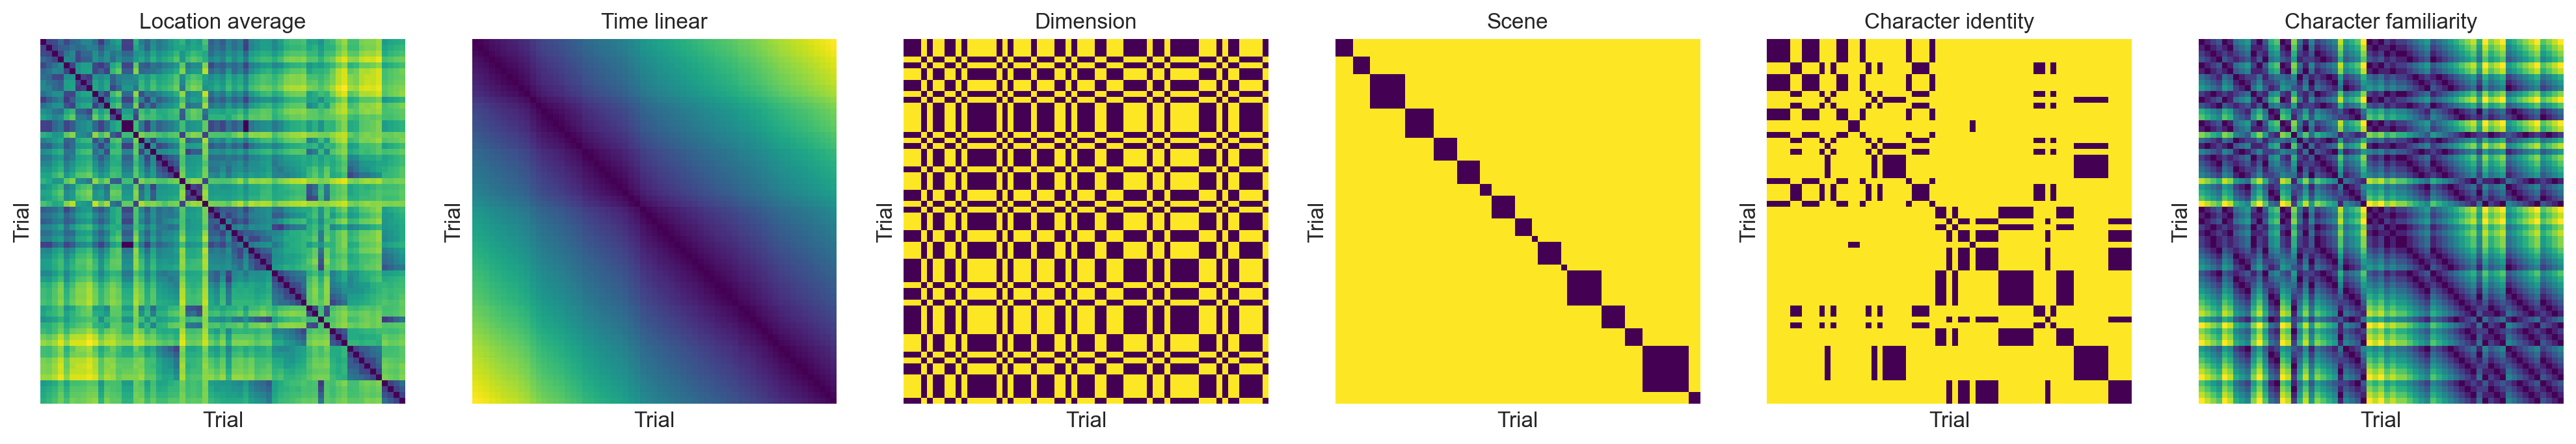

In [4]:
#---------------------------------- compute RDVs for confounds

onset    = decision_trials['onset'].values
char_fam = decision_trials['character_decision_num'].values
char_id  = decision_trials['character_role_num'].values
scene    = pd.factorize(decision_trials['scene'].values, sort=False)[0]
dims     = (decision_trials['dimension'].values == 'affil').astype(int)



time_linear_rdv, time_quad_rdv = time_poly_basis(onset).T
char_fam_rdv   = pdist(char_fam.reshape(-1, 1), metric='euclidean')
scene_rdv      = pdist(scene.reshape(-1, 1), metric='hamming') 
char_id_rdv    = pdist(char_id.reshape(-1, 1), metric='hamming')
char_same_rdvs = per_character_rdvs(char_id)
dim_rdv        = pdist(dims.reshape(-1, 1), metric='hamming')

confounds = {
    'Time linear':    time_linear_rdv,
    'Time quadratic': time_quad_rdv,
    'Scene': scene_rdv,
    'Char identity':    char_id_rdv,
    'Char familiarity': char_fam_rdv,
    'Dimension': dim_rdv,
}
conf_order = list(confounds.keys())
k = len(conf_order)

#------------------------- average behavioral RDM

rdms = []
for sub_id in incl_subs:
    beh = load_behavior(sub_id, neutrals=True)
    xy   = beh[['affil_coord', 'power_coord']].values
    rdms.append(squareform(pdist(xy, metric='euclidean')))
beh_rdm = np.mean(np.array(rdms), 0)

#------------------------- plot the RDMs

# convert confound RDVs to RDMs
time_linear_rdm = squareform(time_linear_rdv)
time_quad_rdm   = squareform(time_quad_rdv)
char_fam_rdm    = squareform(char_fam_rdv)
scene_rdm       = squareform(scene_rdv)
char_id_rdm     = squareform(char_id_rdv).astype(float)  # 0/1 same-different
char_id_rdms    = {c: squareform(rdv, checks=False) for c, rdv in char_same_rdvs.items()}
dim_rdm         = squareform(dim_rdv)

mats = {
    'Location average': beh_rdm,
    'Time linear':    time_linear_rdm,
    'Dimension': dim_rdm,
    'Scene': scene_rdm,
    'Character identity':    char_id_rdm,
    'Character familiarity': char_fam_rdm,

}
fig, axes = plt.subplots(1, len(mats), figsize=(4.2*len(mats), 4), constrained_layout=True)
for ax, (name, M) in zip(axes, mats.items()):
    vmin, vmax = (0, 1) if "identity" in name.lower() else (0, np.nanmax(M))
    sns.heatmap(M, ax=ax, cmap="viridis", square=True, cbar=False, vmin=vmin, vmax=vmax)
    ax.set_title(name)
    ax.set_xlabel("Trial")
    ax.set_ylabel("Trial")
    # remove the labels for ticks
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()


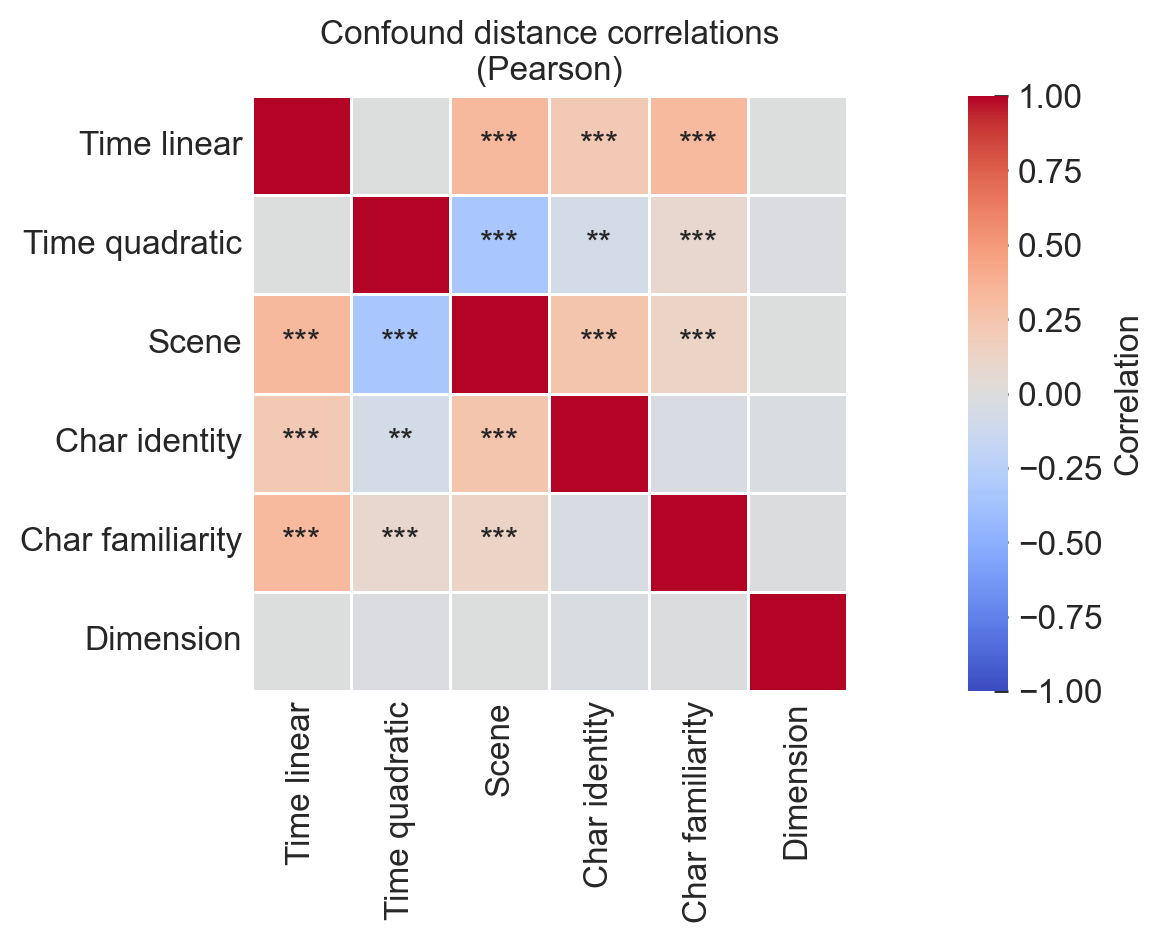

In [5]:
#---------------------------------- compute correlation + p-value matrices

corr_mat = np.eye(k, dtype=float)
p_mat    = np.zeros((k, k), dtype=float)
for i in range(k):
    for j in range(i+1, k):
        r, p = corr_and_p(confounds[conf_order[i]], confounds[conf_order[j]], method=corr_method)
        corr_mat[i, j] = corr_mat[j, i] = r
        p_mat[i, j]    = p_mat[j, i]    = p
corr_df = pd.DataFrame(corr_mat, index=conf_order, columns=conf_order)
p_df    = pd.DataFrame(p_mat,    index=conf_order, columns=conf_order)

annot = np.empty_like(corr_mat, dtype=object)
for i in range(k):
    for j in range(k):
        annot[i, j] = stars_from_p(p_df.iat[i, j]) if i != j else ""
annot_df = pd.DataFrame(annot, index=conf_order, columns=conf_order)

# ---------- plot ----------

fig = plt.figure(figsize=(5.8, 4.6), constrained_layout=True)
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1, 0.05])
ax  = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])

sns.heatmap(
    corr_df, vmin=-1, vmax=1, center=0, cmap="coolwarm",
    annot=annot_df, fmt="", linewidths=.5, square=True,
    cbar=True, cbar_ax=cax, cbar_kws={"label": "Correlation"}, ax=ax
)
ax.set_title(f"Confound distance correlations\n({corr_method.title()})")
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()

## relationships of confound distances to location distances

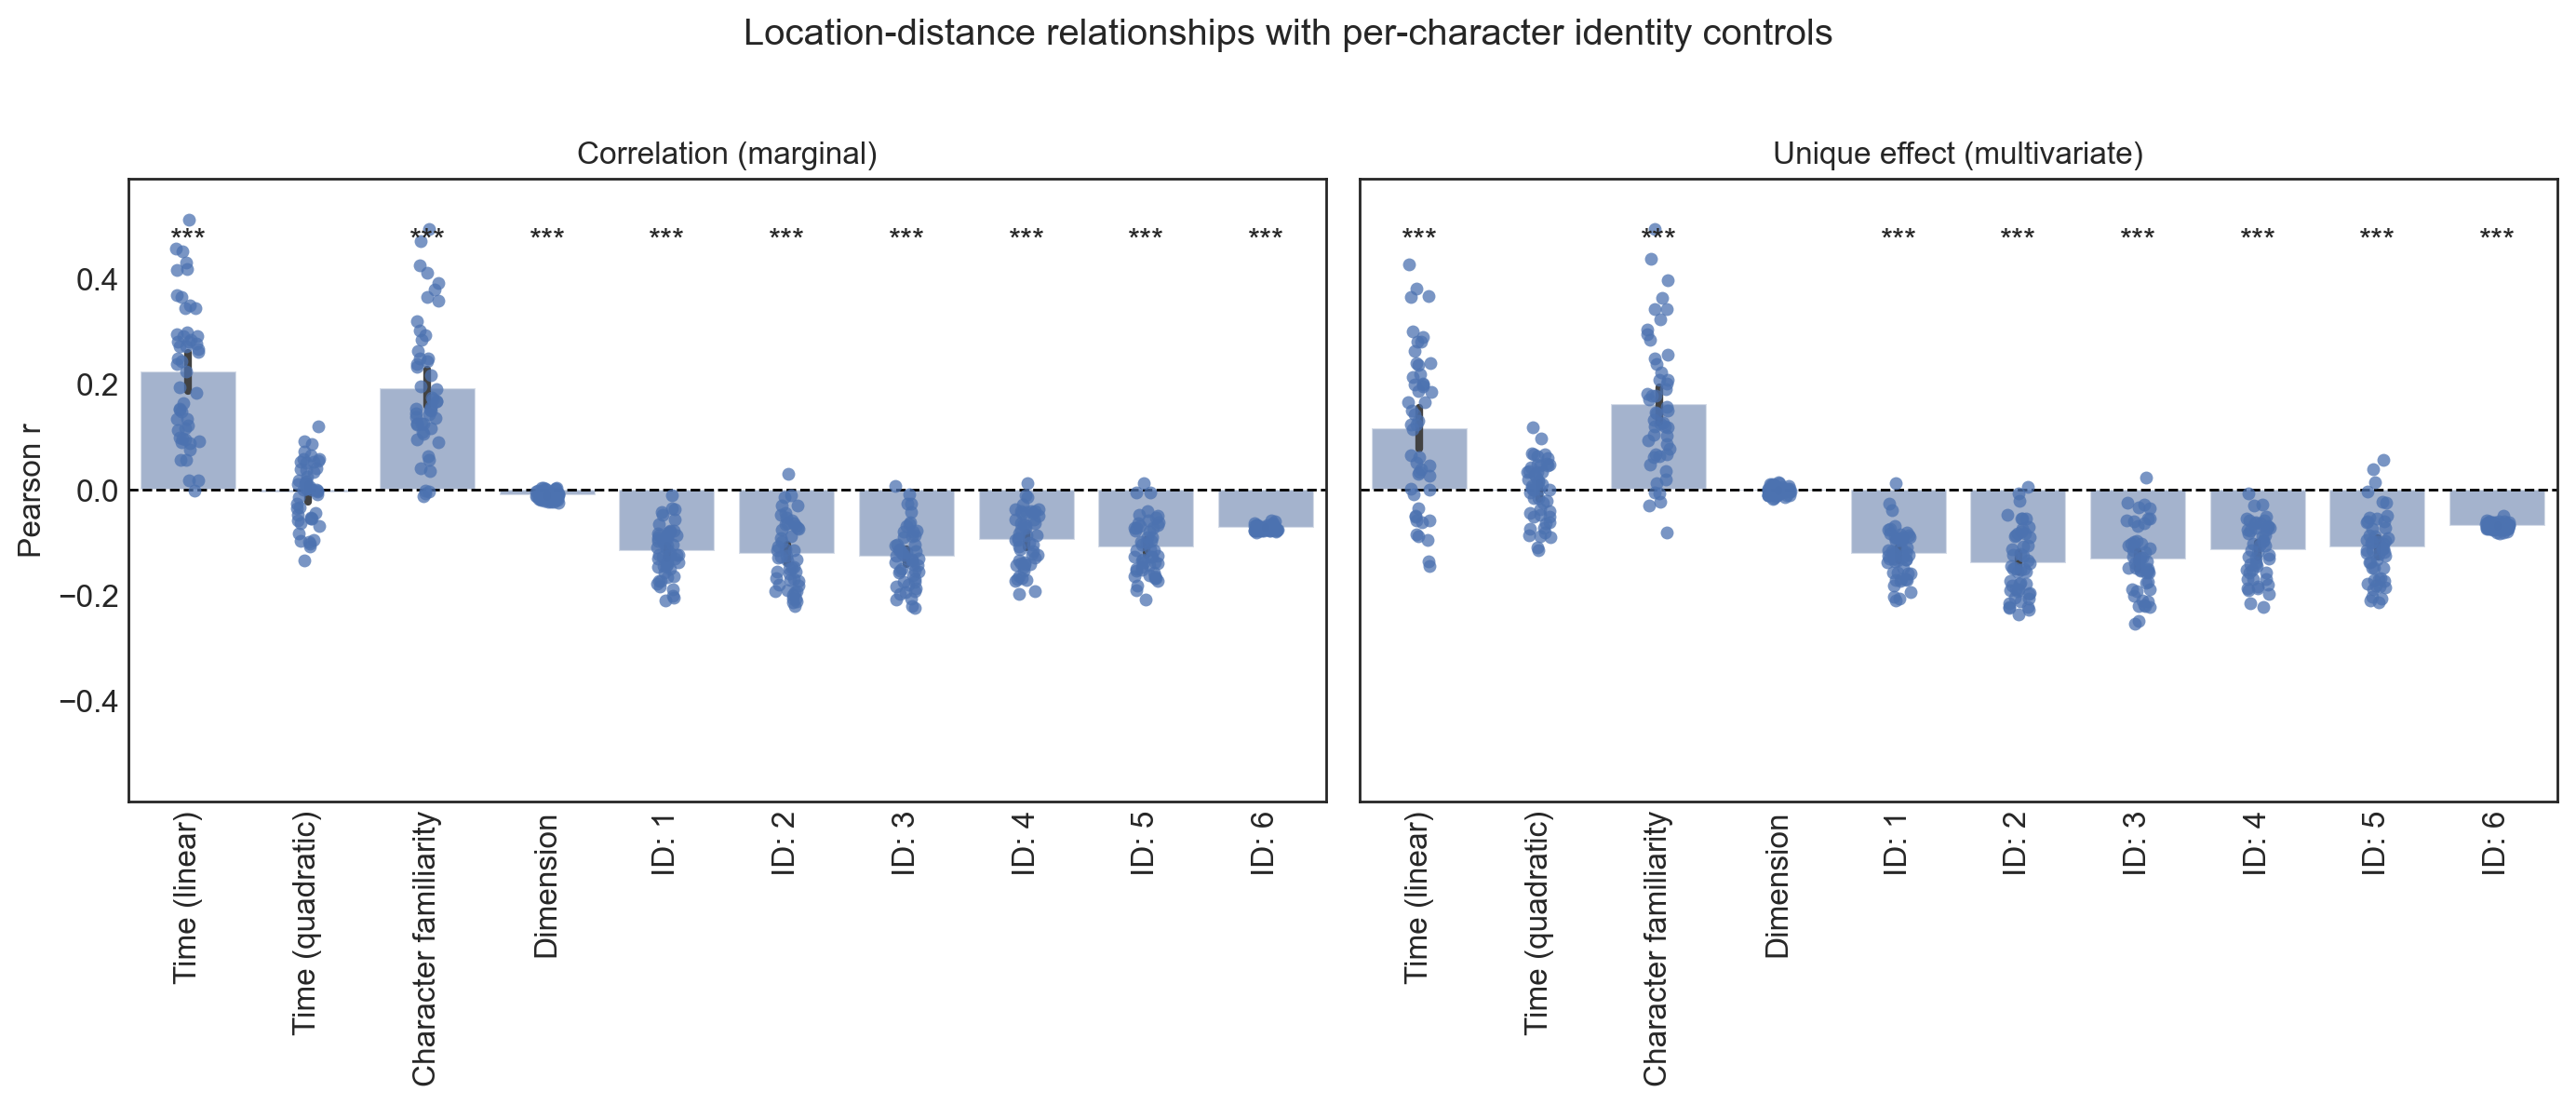

In [6]:
def zscore_cols(A, eps=1e-12):
    A = np.asarray(A, float)
    mu = A.mean(axis=0, keepdims=True)
    sd = A.std(axis=0, ddof=1, keepdims=True)
    return (A - mu) / (sd + eps)

def add_zero_stars_fixed(ax, x_names, vals_by_name, y_pos):
    """Place *** ** * at a fixed vertical position y_pos for readability."""
    for i, name in enumerate(x_names):
        v = np.asarray(vals_by_name[name], float)
        v = v[np.isfinite(v)]
        if v.size == 0:
            continue
        p = ttest_1samp(v, 0.0, nan_policy="omit").pvalue
        star = "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 5e-2 else ""
        if star:
            ax.text(i, y_pos, star, ha="center", va="bottom", fontsize=12)

# ---------- build confounds

confounds = {
    "Time (linear)":           time_linear_rdv,
    "Time (quadratic)":        time_quad_rdv,
    "Character familiarity":   char_fam_rdv,
    'Dimension': dim_rdv,
}

for char_name, rdv in char_same_rdvs.items():
    confounds[f"ID: {char_name}"] = rdv
conf_order = list(confounds.keys())

# ---------- collect per-subject metrics ----------

rows_corr = []   # marginal Pearson r
rows_beta = []   # standardized betas from multivariate regression
X_conf = np.column_stack([confounds[k] for k in conf_order])  # [N_pairs, P]
Xz     = zscore_cols(X_conf)
for sub_id in incl_subs:
    beh = load_behavior(sub_id, neutrals=True)
    xy   = beh[['affil_coord', 'power_coord']].values
    y    = pdist(xy, metric='euclidean')          # [N_pairs]
    yz   = zscore_cols(y.reshape(-1, 1)).ravel()  # standardized y for standardized betas

    # (1) marginal Pearson correlations per confound
    for name in conf_order:
        rows_corr.append({"sub_id": sub_id, "confound": name, "value": corr_only(confounds[name], y)})

    # (2) standardized betas (unique effects controlling others)
    lr = LinearRegression(fit_intercept=True).fit(Xz, yz)
    for name, b in zip(conf_order, lr.coef_):
        rows_beta.append({"sub_id": sub_id, "confound": name, "value": float(b)})

corr_df = pd.DataFrame(rows_corr)
beta_df = pd.DataFrame(rows_beta)

# ---------- plot

global_max = np.nanmax(np.abs(pd.concat([corr_df["value"], beta_df["value"]], ignore_index=True).values))
ylim = 1.15 * (global_max if np.isfinite(global_max) and global_max > 0 else 1.0)
star_y = 0.75 * ylim  # constant star height across both plots

fig, axes = plt.subplots(1, 2, figsize=(max(12, 0.6*len(conf_order)+8), 5.8),
                         constrained_layout=True, sharey=True)
color = sns.color_palette("deep")[0]

# Left: marginal Pearson correlations
ax = axes[0]
sns.barplot(data=corr_df, x="confound", y="value", order=conf_order,
            errorbar="ci", color=color, alpha=0.55, ax=ax)
sns.stripplot(data=corr_df, x="confound", y="value", order=conf_order,
              dodge=False, alpha=0.75, linewidth=0, color=color, ax=ax)
ax.axhline(0, color="k", lw=1, ls="--")
ax.set_ylim(-ylim, ylim)
ax.set_xlabel("")
ax.set_ylabel("Pearson r")
ax.set_title("Correlation (marginal)")
ax.tick_params(axis="x", rotation=90)
vals_by_name = {n: corr_df.loc[corr_df["confound"] == n, "value"].values for n in conf_order}
add_zero_stars_fixed(ax, conf_order, vals_by_name, y_pos=star_y)

# Right: standardized betas (unique effects)
ax = axes[1]
sns.barplot(data=beta_df, x="confound", y="value", order=conf_order,
            errorbar="ci", color=color, alpha=0.55, ax=ax)
sns.stripplot(data=beta_df, x="confound", y="value", order=conf_order,
              dodge=False, alpha=0.75, linewidth=0, color=color, ax=ax)
ax.axhline(0, color="k", lw=1, ls="--")
ax.set_ylim(-ylim, ylim)
ax.set_xlabel("")
ax.set_ylabel("β (standardized)")
ax.set_title("Unique effect (multivariate)")
ax.tick_params(axis="x", rotation=90)
vals_by_name = {n: beta_df.loc[beta_df["confound"] == n, "value"].values for n in conf_order}
add_zero_stars_fixed(ax, conf_order, vals_by_name, y_pos=star_y)

fig.suptitle("Location-distance relationships with per-character identity controls", y=1.02)
plt.tight_layout()

In [7]:
from scipy.stats import ttest_1samp  # already used in add_zero_stars_fixed; safe to re-import

def _print_group_t(df, label):
    """
    For a long df with columns ['confound','value'], print one-sample t-tests vs 0
    across subjects, grouped by confound. Mirrors the star test used in the plots.
    """
    print(f"\n{label}")
    print("-" * len(label))
    for name, sub in df.groupby("confound", sort=False):
        v = np.asarray(sub["value"], float)
        v = v[np.isfinite(v)]
        if v.size == 0:
            continue
        n = v.size
        m = v.mean()
        s = v.std(ddof=1) if n > 1 else np.nan
        t, p = ttest_1samp(v, 0.0, nan_policy="omit")
        print(f"{name:>28s}  n={n:2d}  mean={m: .3f}  sd={s: .3f}  t={t: .2f}  p={p: .3g}")


corr_df = pd.DataFrame(rows_corr)
beta_df = pd.DataFrame(rows_beta)

# ---------- print numeric summaries (matches what the stars test)
_print_group_t(corr_df, "Marginal Pearson r (one-sample t vs 0 across subjects)")
_print_group_t(beta_df, "Standardized betas (one-sample t vs 0 across subjects)")



Marginal Pearson r (one-sample t vs 0 across subjects)
------------------------------------------------------
               Time (linear)  n=50  mean= 0.225  sd= 0.130  t= 12.24  p= 1.6e-16
            Time (quadratic)  n=50  mean=-0.005  sd= 0.058  t=-0.55  p= 0.586
       Character familiarity  n=50  mean= 0.193  sd= 0.127  t= 10.79  p= 1.54e-14
                   Dimension  n=50  mean=-0.011  sd= 0.008  t=-9.64  p= 6.71e-13
                       ID: 1  n=50  mean=-0.116  sd= 0.047  t=-17.44  p= 1.16e-22
                       ID: 2  n=50  mean=-0.121  sd= 0.063  t=-13.58  p= 3.16e-18
                       ID: 3  n=50  mean=-0.126  sd= 0.056  t=-16.03  p= 4e-21
                       ID: 4  n=50  mean=-0.095  sd= 0.052  t=-12.87  p= 2.49e-17
                       ID: 5  n=50  mean=-0.109  sd= 0.051  t=-15.18  p= 3.73e-20
                       ID: 6  n=50  mean=-0.072  sd= 0.005  t=-103.00  p= 6.13e-59

Standardized betas (one-sample t vs 0 across subjects)
---------------------